<a href="https://colab.research.google.com/github/fruct49/ml_practice/blob/main/%22%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%965_%D0%9B%D0%B8%D0%BD%D0%B5%D0%B9%D0%BD%D0%B0%D1%8F_%D0%B8_%D0%BB%D0%BE%D0%B3%D0%B8%D1%81%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%81%D0%B8%D1%8F_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **Практическая работа №5. Линейная и логистическая регрессия**



## **Линейная регрессия**



### **Задание №1. Прогнозирование продаж автомобилей**

- **Шаг 1**: Загрузите набор данных о продажах автомобилей, содержащий информацию о цене, возрасте, пробеге и других характеристиках.
  - **Совет №1**: Проверьте данные на наличие пропущенных значений и выбросов. Используйте `pandas` для обнаружения пропусков (`df.isnull().sum()`) и выбросов (например, с помощью метода межквартильного размаха - `df.boxplot()`).
  - **Совет №2**: Для пропущенных значений используйте стратегию заполнения средними значениями или медианой, чтобы минимизировать влияние на распределение данных (`df.fillna()`).




- Ссылка на набор данных: https://www.kaggle.com/datasets/gagandeep16/car-sales

In [2]:
import kagglehub, pandas as pd, numpy as np, seaborn as sns, matplotlib.pyplot as plt
from kagglehub import KaggleDatasetAdapter

cars_df = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "gagandeep16/car-sales", "Car_sales.csv")

cars_df.fillna(cars_df.median(numeric_only=True), inplace=True)

q1, q3 = cars_df['Price_in_thousands'].quantile([.25, .75])
iqr = q3 - q1
cars_df = cars_df[cars_df['Price_in_thousands'].between(q1 - 1.5*iqr, q3 + 1.5*iqr)]

print(f"Данные готовы. Осталось строк: {len(cars_df)}")

100%|██████████| 15.6k/15.6k [00:00<00:00, 12.7MB/s]

Данные готовы. Осталось строк: 148


- **Шаг 2**: Проведите предварительный анализ данных:
  - Постройте гистограммы для каждого числового признака, чтобы понять их распределение.
  - Постройте диаграммы рассеяния для выявления зависимостей между признаками и целевой переменной (ценой).
  - **Совет**: Используйте корреляционную матрицу для выявления сильных линейных зависимостей между признаками.

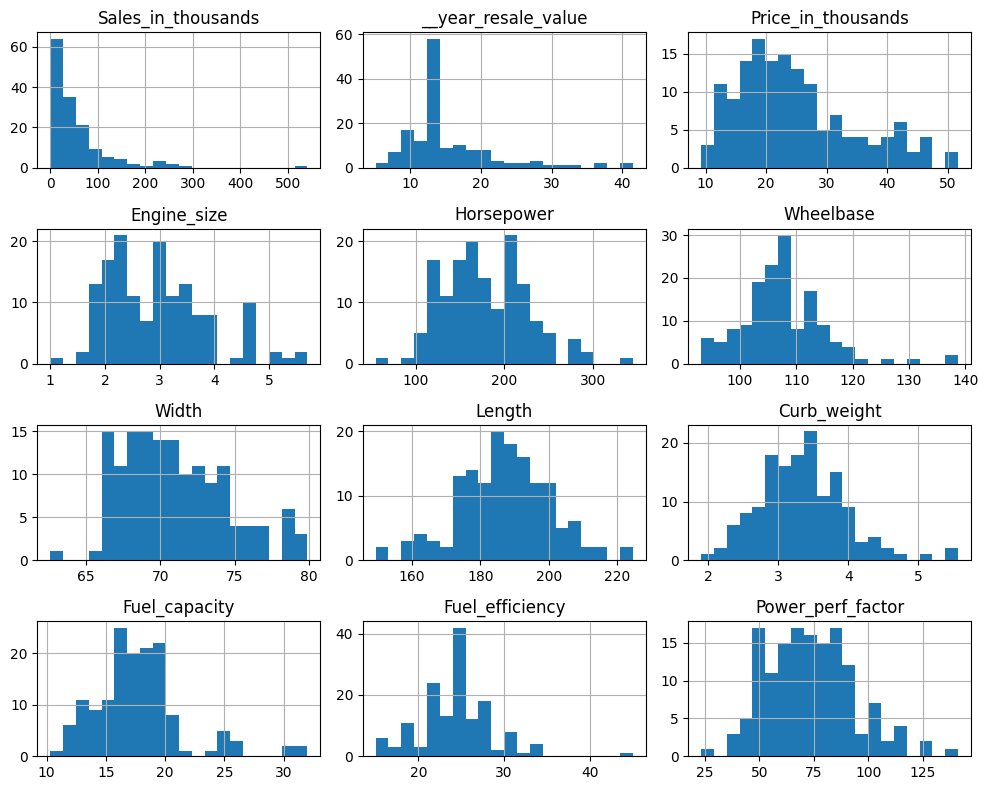

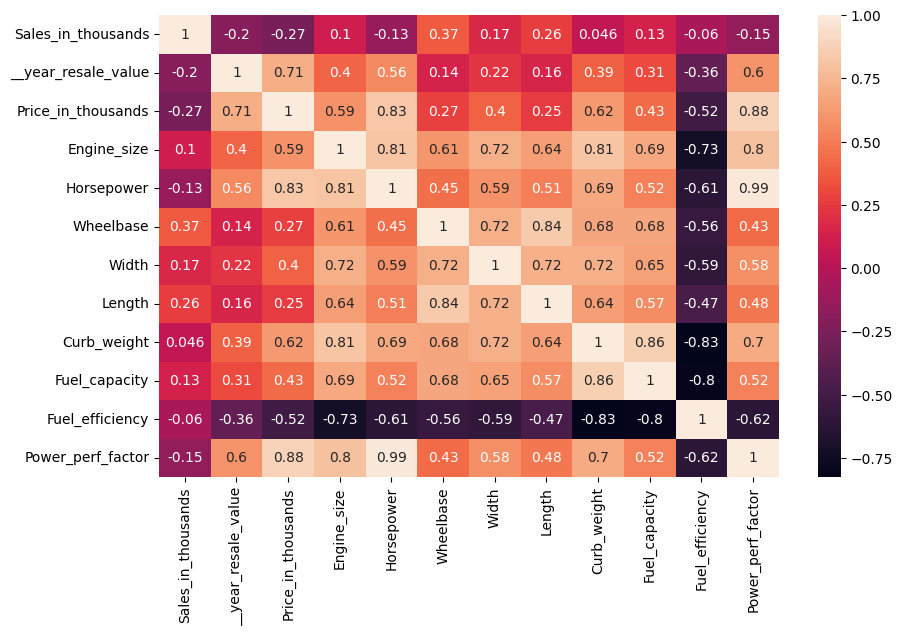

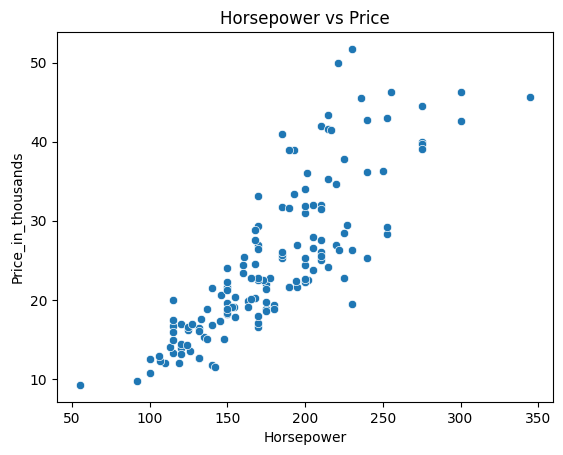

In [3]:
cars_df.hist(figsize=(10, 8), bins=20)
plt.tight_layout(); plt.show()

plt.figure(figsize=(10, 6))
sns.heatmap(cars_df.corr(numeric_only=True), annot=True)
plt.show()

sns.scatterplot(x='Horsepower', y='Price_in_thousands', data=cars_df)
plt.title("Horsepower vs Price")
plt.show()

- **Шаг 3**: Разделите данные на обучающую и тестовую выборки (например, 70% на обучение и 30% на тестирование) с помощью `train_test_split` из `sklearn.model_selection`.

In [4]:
from sklearn.model_selection import train_test_split

features = ['Engine_size', 'Horsepower', 'Wheelbase', 'Width', 'Length', 'Curb_weight', 'Fuel_capacity', 'Fuel_efficiency']
x_data = cars_df[features]
y_val = cars_df['Price_in_thousands']

x_train, x_test, y_train, y_test = train_test_split(x_data, y_val, test_size=0.3, random_state=42)

- **Шаг 4**: Постройте и обучите модели линейной регрессии с различными типами регуляризации:
  - Обучите базовую модель `LinearRegression` (без регуляризации).
  - Обучите модель **Ridge** (L2-регуляризация) с подбором гиперпараметра `alpha` с помощью `GridSearchCV`.
  - Обучите модель **Lasso** (L1-регуляризация) с подбором гиперпараметра `alpha` с помощью `RandomizedSearchCV`.
  - Обучите модель **ElasticNet** (комбинация L1 и L2) с подбором гиперпараметров `alpha` и `l1_ratio` с помощью `GridSearchCV` и/или `RandomizedSearchCV`.
  - **Совет**: Используйте `np.logspace(-4, 4, 50)` для генерации сетки значений `alpha`.



In [5]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

alphas = np.logspace(-4, 4, 50)
models_pool = {}

models_pool['Linear'] = LinearRegression().fit(x_train, y_train)

ridge_gs = GridSearchCV(Ridge(), {'alpha': alphas}, cv=5).fit(x_train, y_train)
models_pool['Ridge'] = ridge_gs.best_estimator_

lasso_rs = RandomizedSearchCV(Lasso(), {'alpha': alphas}, n_iter=20, cv=5, random_state=42).fit(x_train, y_train)
models_pool['Lasso'] = lasso_rs.best_estimator_

elastic_gs = GridSearchCV(ElasticNet(), {'alpha': alphas, 'l1_ratio': [.2, .5, .8]}, cv=5).fit(x_train, y_train)
models_pool['ElasticNet'] = elastic_gs.best_estimator_

- **Шаг 5**: Оцените качество всех моделей с использованием метрик MSE, RMSE, MAE и R².
  - Выведите значения метрик для каждой модели и интерпретируйте их.


- **Шаг 6**: Визуализируйте результаты:
  - Постройте график зависимости предсказанных цен от фактических для каждой модели.





- **Шаг 7**: **Сравните все модели между собой по целевым метрикам (MSE, RMSE, MAE, R²)**:
  - Создайте сводную таблицу с метриками для всех моделей.
  - Определите лучшую модель и выведите для неё все метрики, а также оптимальные гиперпараметры.


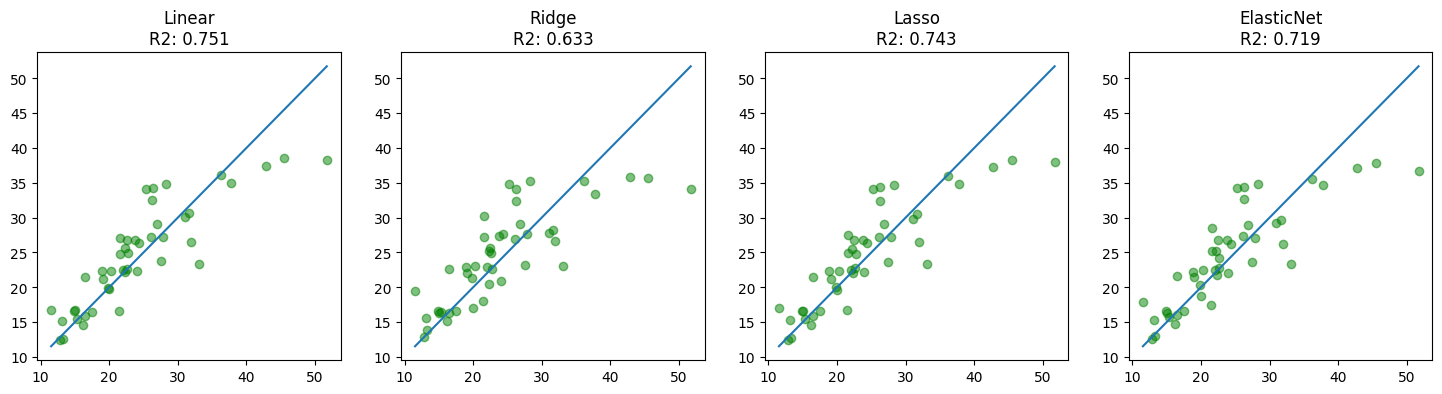

Сводная таблица метрик:
        Model        MSE      RMSE       MAE        R2
0      Linear  18.508600  4.302162  3.140921  0.751130
2       Lasso  19.129475  4.373726  3.203897  0.742782
3  ElasticNet  20.902743  4.571952  3.358810  0.718938
1       Ridge  27.282804  5.223294  3.924471  0.633151

Итог:
Лучшая модель: Linear с R2 = 0.7511


In [6]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

results_list = []
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for i, (name, m) in enumerate(models_pool.items()):
    preds = m.predict(x_test)

    mse = mean_squared_error(y_test, preds)
    r2, mae = r2_score(y_test, preds), mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mse)

    results_list.append({'Model': name, 'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2})

    axes[i].scatter(y_test, preds, alpha=0.5, color='green')
    axes[i].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
    axes[i].set_title(f"{name}\nR2: {r2:.3f}")

plt.show()

res_table = pd.DataFrame(results_list).sort_values('R2', ascending=False)
print(f"Сводная таблица метрик:\n{res_table}")

best_m = res_table.iloc[0]
print(f"\nИтог:")
print(f"Лучшая модель: {best_m['Model']} с R2 = {best_m['R2']:.4f}")

---



### **Задание №2. Влияние погодных условий на урожайность**




- **Шаг 1**: Загрузите набор данных о погодных условиях и урожайности сельскохозяйственных культур.
  - **Совет**: Проверьте данные на наличие пропущенных значений и выбросов. Используйте стратегию заполнения пропусков средними значениями или медианой.

- Ссылка на набор данных: https://www.kaggle.com/datasets/waqi786/climate-change-impact-on-agriculture


In [7]:
import kagglehub, pandas as pd, numpy as np, seaborn as sns, matplotlib.pyplot as plt
from kagglehub import KaggleDatasetAdapter

file_name = "climate_change_impact_on_agriculture_2024.csv"
df = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "waqi786/climate-change-impact-on-agriculture", file_name)

num_cols = df.select_dtypes(include=[np.number]).columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())

target = 'Crop_Yield_MT_per_HA'

q1, q3 = df[target].quantile([0.25, 0.75])
iqr = q3 - q1
df = df[df[target].between(q1 - 1.5*iqr, q3 + 1.5*iqr)]

print("Данные загружены и очищены. Размер:", df.shape)

100%|██████████| 1.01M/1.01M [00:00<00:00, 95.9MB/s]

Данные загружены и очищены. Размер: (10000, 15)





- **Шаг 2**: Выполните анализ данных:
  - Постройте корреляционную матрицу для выявления зависимостей между признаками.
  - Постройте диаграммы рассеяния для ключевых признаков.
  - **Совет**: Удалите или преобразуйте признаки с низкой корреляцией с целевой переменной, чтобы улучшить модель.



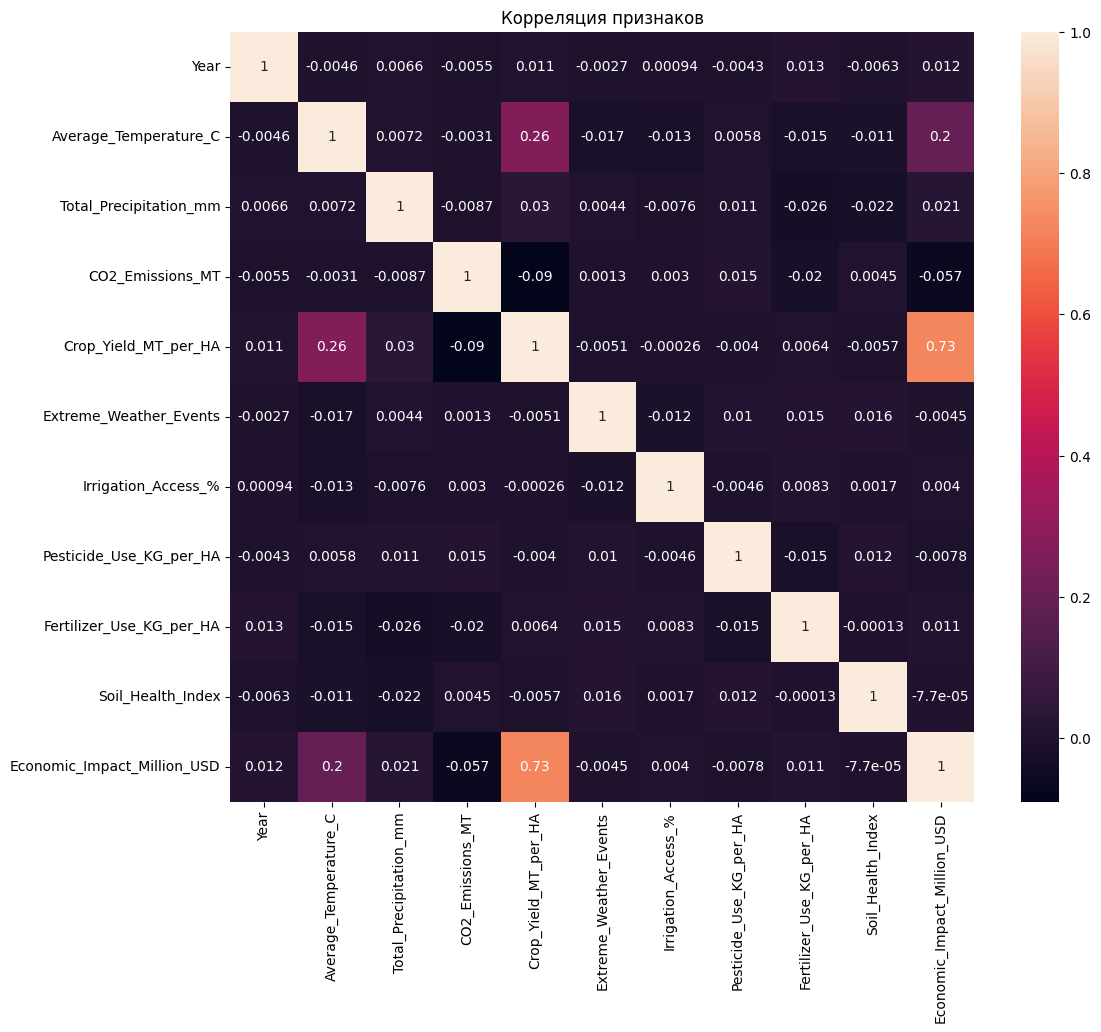

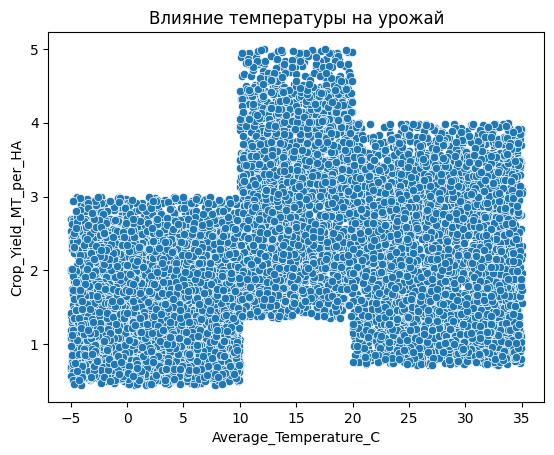

Отобранные признаки для обучения: ['Average_Temperature_C', 'Total_Precipitation_mm', 'CO2_Emissions_MT', 'Economic_Impact_Million_USD']


In [8]:
plt.figure(figsize=(12, 10))
corr_matrix = df[num_cols].corr()
sns.heatmap(corr_matrix, annot=True)
plt.title("Корреляция признаков")
plt.show()

sns.scatterplot(x='Average_Temperature_C', y=target, data=df)
plt.title("Влияние температуры на урожай")
plt.show()

target_corr = corr_matrix[target].abs()
useful_features = target_corr[target_corr > 0.02].index.tolist()
useful_features.remove(target)

print(f"Отобранные признаки для обучения: {useful_features}")

- **Шаг 3**: Разделите данные на обучающую и тестовую выборки.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df[useful_features]
y = df[target]

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

x_train_scaled = pd.DataFrame(x_train_scaled, columns=useful_features)
x_test_scaled = pd.DataFrame(x_test_scaled, columns=useful_features)



- **Шаг 4**: Постройте и обучите модели линейной регрессии с различными типами регуляризации для оценки влияния температуры и уровня осадков на урожайность:
  - Обучите базовую модель `LinearRegression` (без регуляризации).
  - Обучите модель **Ridge** (L2-регуляризация) с подбором гиперпараметра `alpha` с помощью `RandomizedSearchCV`.
  - Обучите модель **Lasso** (L1-регуляризация) с подбором гиперпараметра `alpha` с помощью `GridSearchCV`.
  - Обучите модель **ElasticNet** с подбором гиперпараметров `alpha` и `l1_ratio` с помощью `GridSearchCV` и/или `RandomizedSearchCV` .

In [10]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np

models = {}
alphas = np.logspace(-4, 4, 50)

models['Linear'] = LinearRegression().fit(x_train_scaled, y_train)

models['Ridge'] = RandomizedSearchCV(Ridge(), {'alpha': alphas}, n_iter=20, cv=5, random_state=1).fit(x_train_scaled, y_train).best_estimator_

models['Lasso'] = GridSearchCV(Lasso(), {'alpha': alphas}, cv=5).fit(x_train_scaled, y_train).best_estimator_

elastic_params = {'alpha': alphas, 'l1_ratio': [0.1, 0.5, 0.9]}
models['ElasticNet'] = RandomizedSearchCV(ElasticNet(), elastic_params, n_iter=20, cv=5, random_state=1).fit(x_train_scaled, y_train).best_estimator_

- **Шаг 5**: Проведите оценку точности всех моделей.
  - Выведите значения метрик MSE, RMSE, MAE и R² для каждой модели и интерпретируйте их.

In [11]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

res_list = []
for name, m in models.items():
    preds = m.predict(x_test_scaled)
    mse = mean_squared_error(y_test, preds)
    res_list.append({
        'Модель': name,
        'MSE': mse,
        'RMSE': np.sqrt(mse),
        'MAE': mean_absolute_error(y_test, preds),
        'R2': r2_score(y_test, preds)
    })

res_df = pd.DataFrame(res_list).set_index('Модель')
print(res_df)

                 MSE      RMSE       MAE        R2
Модель                                            
Linear      0.449622  0.670539  0.540852  0.558519
Ridge       0.449661  0.670567  0.540829  0.558481
Lasso       0.449623  0.670539  0.540844  0.558518
ElasticNet  0.449631  0.670545  0.540835  0.558510




- **Шаг 6**: Визуализируйте данные и результаты моделей:
  - Постройте графики зависимости предсказанных значений от фактических для каждой модели.

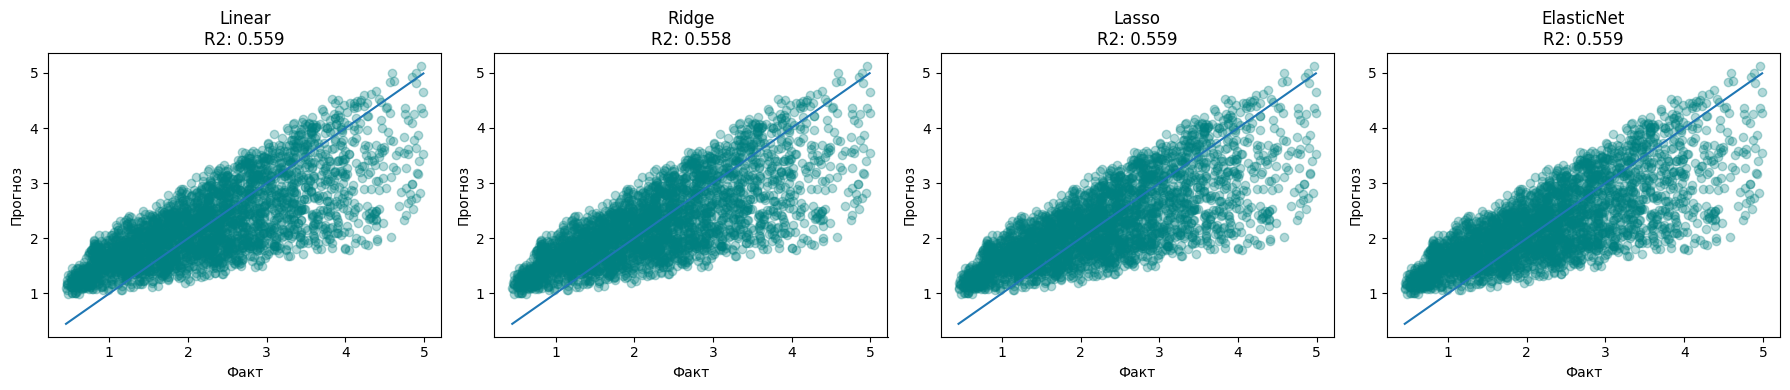

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for i, (name, m) in enumerate(models.items()):
    preds = m.predict(x_test_scaled)
    axes[i].scatter(y_test, preds, alpha=0.3, color='teal')
    axes[i].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
    axes[i].set_title(f"{name}\nR2: {r2_score(y_test, preds):.3f}")
    axes[i].set_xlabel("Факт")
    axes[i].set_ylabel("Прогноз")

plt.tight_layout()
plt.show()

- **Шаг 7**: **Сравните все модели между собой по целевым метрикам (MSE, RMSE, MAE, R²)**:
  - Создайте сводную таблицу с метриками для всех моделей.
  - Определите лучшую модель и выведите для неё все метрики, а также оптимальные гиперпараметры.

In [13]:
res_table = res_df.sort_values(by='R2', ascending=False)
print(f"Сводная таблица метрик:\n{res_table}\n")

best_m_name = res_table.index[0]
best_m_obj = models[best_m_name]
best_metrics = res_table.loc[best_m_name]

print(f"Лучшая модель: {best_m_name}")
print(f"Метрики: R2: {best_metrics['R2']:.4f}, MSE: {best_metrics['MSE']:.4f}, MAE: {best_metrics['MAE']:.4f}")

if best_m_name != 'Linear':
    config = best_m_obj.get_params()
    print(f"Оптимальное Alpha: {config.get('alpha'):.6f}")
    if 'l1_ratio' in config:
        print(f"Параметр L1_ratio: {config.get('l1_ratio')}")

Сводная таблица метрик:
                 MSE      RMSE       MAE        R2
Модель                                            
Linear      0.449622  0.670539  0.540852  0.558519
Lasso       0.449623  0.670539  0.540844  0.558518
ElasticNet  0.449631  0.670545  0.540835  0.558510
Ridge       0.449661  0.670567  0.540829  0.558481

Лучшая модель: Linear
Метрики: R2: 0.5585, MSE: 0.4496, MAE: 0.5409


- **Шаг 8: Проанализируйте влияние признаков на урожайность**

  - На основе лучшей модели проведите анализ важности признаков:

    - Извлеките коэффициенты (`coef_`) лучшей модели и сопоставьте их с названиями признаков.
    - Визуализируйте важность признаков с помощью горизонтальной столбчатой диаграммы.
    - Проинтерпретируйте результаты: определите, какие погодные факторы (температура, осадки, CO₂ и др.) оказывают наибольшее положительное и отрицательное влияние на урожайность.
    - **Совет**: Для модели Lasso обратите внимание на признаки с нулевыми коэффициентами — они были исключены как незначимые.
    - **Совет**: Если данные были стандартизированы (`StandardScaler`), коэффициенты можно напрямую сравнивать по абсолютной величине для оценки относительной важности.



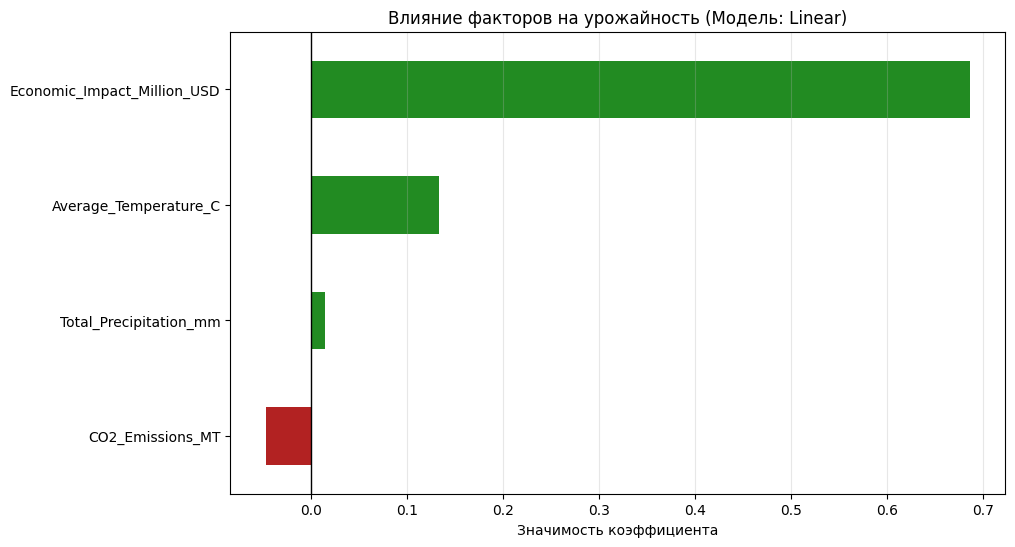

Итоги анализа:
Положительно влияют: Total_Precipitation_mm, Average_Temperature_C, Economic_Impact_Million_USD
Отрицательно влияют: CO2_Emissions_MT
Самый важный фактор: Economic_Impact_Million_USD (вес: 0.6869)


In [14]:
feature_weights = pd.Series(best_m_obj.coef_, index=useful_features).sort_values()

plt.figure(figsize=(10, 6))
colors = ['firebrick' if val < 0 else 'forestgreen' for val in feature_weights]
feature_weights.plot(kind='barh', color=colors)
plt.axvline(0, color='black', lw=1)
plt.title(f"Влияние факторов на урожайность (Модель: {best_m_name})")
plt.xlabel("Значимость коэффициента")
plt.grid(axis='x', alpha=0.3)
plt.show()

plus_factors = feature_weights[feature_weights > 0].index.tolist()
minus_factors = feature_weights[feature_weights < 0].index.tolist()
main_factor = feature_weights.abs().idxmax()

print(f"Итоги анализа:")
print(f"Положительно влияют: {', '.join(plus_factors)}")
print(f"Отрицательно влияют: {', '.join(minus_factors)}")
print(f"Самый важный фактор: {main_factor} (вес: {feature_weights[main_factor]:.4f})")

#### **Интерпретация результатов (пример формулировки для отчёта):**


**[ТРЕБУЕТСЯ ЗАПОЛНИТЬ!]**


> На основе анализа коэффициентов лучшей модели установлено, что:
>
Положительно влияют: Total_Precipitation_mm, Average_Temperature_C, Economic_Impact_Million_USD

Отрицательно влияют: CO2_Emissions_MT
Самый важный фактор: Economic_Impact_Million_USD (вес: 0.6869)
> - Наиболее значимым фактором является Economic_Impact_Million_USD с коэффициентом 0.6869, что означает: при увеличении данного показателя на 1 единицу (при прочих равных) урожайность изменяется на 0.6869 единиц.

---



## **Логистическая регрессия**



### **Задание №3. Классификация клиентов банка**

- **Шаг 1**: Загрузите набор данных о клиентах банка, включающий данные о возрасте, доходе, кредитной истории и других характеристиках.
  - **Совет**: Проверьте данные на наличие пропущенных значений и выбросов. Используйте стратегию заполнения пропусков средними значениями или медианой.



- Ссылка на набор данных: https://www.kaggle.com/datasets/henriqueyamahata/bank-marketing/data

In [15]:
import kagglehub, os, pandas as pd, numpy as np

dataset_path = kagglehub.dataset_download("henriqueyamahata/bank-marketing")
full_path = os.path.join(dataset_path, 'bank-additional-full.csv')

bank_df = pd.read_csv(full_path, sep=';')

bank_df.fillna(bank_df.median(numeric_only=True), inplace=True)

bank_df['y'] = bank_df['y'].map({'yes': 1, 'no': 0})

print(f"Колонки теперь разделены: {bank_df.columns.tolist()}")
print(bank_df.head(3))

100%|██████████| 393k/393k [00:00<00:00, 79.9MB/s]

Extracting files...
Колонки теперь разделены: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']
   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.price.idx  cons.conf.idx  euribor3m  nr.employed  y  
0          93.994

- **Шаг 2**: Проведите анализ данных и предобработку:
  - Закодируйте категориальные переменные с помощью `OneHotEncoder` или `pd.get_dummies`.
  - Нормализуйте числовые признаки с помощью `StandardScaler` для улучшения обучения модели.
  - **Совет**: Убедитесь, что все признаки имеют одинаковый масштаб, чтобы избежать доминирования одного признака над другими.

In [16]:
from sklearn.preprocessing import StandardScaler

bank_final = pd.get_dummies(bank_df, drop_first=True)

X = bank_final.drop('y', axis=1)
y = bank_final['y']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print(f"Готово. Итоговое количество признаков: {X_scaled.shape[1]}")

Готово. Итоговое количество признаков: 53


- **Шаг 3**: Разделите данные на обучающую и тестовую выборки.

In [17]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=42, stratify=y)

- **Шаг 4**: Постройте и обучите модели логистической регрессии с различными типами регуляризации для предсказания вероятности открытия депозитного счета клиентом:
  - Обучите модель `LogisticRegression` с **L2-регуляризацией** (`penalty='l2'`) и подбором гиперпараметра `C` с помощью `GridSearchCV`.
  - Обучите модель `LogisticRegression` с **L1-регуляризацией** (`penalty='l1'`, `solver='saga'`) и подбором гиперпараметра `C` с помощью `RandomizedSearchCV`.
  - Обучите модель `LogisticRegression` с **ElasticNet-регуляризацией** (`penalty='elasticnet'`, `solver='saga'`) и подбором гиперпараметров `C` и `l1_ratio` с помощью `GridSearchCV` и/или `RandomizedSearchCV` .
  - **Совет**: Для L1 и ElasticNet используйте `solver='saga'`, так как он поддерживает оба типа регуляризации.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

models = {}
c_space = np.logspace(-3, 2, 10)

l2_model = GridSearchCV(LogisticRegression(penalty='l2', max_iter=1000),
                        {'C': c_space}, cv=5).fit(x_train, y_train)
models['L2_Ridge'] = l2_model.best_estimator_

l1_model = RandomizedSearchCV(LogisticRegression(penalty='l1', solver='saga', max_iter=1000),
                              {'C': c_space}, n_iter=5, cv=5, random_state=42).fit(x_train, y_train)
models['L1_Lasso'] = l1_model.best_estimator_

en_model = GridSearchCV(LogisticRegression(penalty='elasticnet', solver='saga', max_iter=1000),
                        {'C': c_space, 'l1_ratio': [0.5]}, cv=5).fit(x_train, y_train)
models['ElasticNet'] = en_model.best_estimator_

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which 


- **Шаг 5**: Оцените качество всех моделей с использованием метрик точности (Accuracy), полноты (Recall), точности (Precision) и F1-меры.
  - Выведите значения метрик для каждой модели и интерпретируйте их. Обратите внимание на баланс между точностью и полнотой.
  - Постройте матрицу ошибок для каждой модели с помощью `confusion_matrix` и визуализируйте их с помощью `seaborn.heatmap`.

In [ ]:
# Ваш код

- **Шаг 6**: Визуализируйте ROC-кривые для всех моделей и вычислите AUC для оценки.
  - Используйте `roc_curve` и `auc` из `sklearn.metrics` для построения и расчёта.
  - Постройте все ROC-кривые на одном графике для наглядного сравнения.



In [ ]:
# Ваш код

- **Шаг 7**: **Сравните все модели между собой по целевым метрикам (Accuracy, Precision, Recall, F1, AUC)**:
  - Создайте сводную таблицу с метриками для всех моделей.
  - Определите лучшую модель и выведите для неё все метрики, оптимальные гиперпараметры и матрицу ошибок.

In [ ]:
# Ваш код